<a href="https://colab.research.google.com/github/msrscs/ia-ciberseguranca/blob/main/aula3_ml_ciberseguranca_cicids2017_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA para Cibersegurança — Aula 3
## Dados e features em segurança: classificação de ataques e clustering (CIC-IDS2017)

**Dupla:** `MAURO SÉRGIO REZENDE DA SILVA`  ·  `SILVIO BARROS TENÓRIO`

> Rodem as células na ordem.

Nesta aula prática vamos trabalhar com **tráfego de rede real** do CIC-IDS2017 e percorrer, de ponta a ponta:
dados → EDA → preparação → **Random Forest** (supervisionado) → feature importance → **K-Means** (não supervisionado) → comparação.

O foco é **entender os dados e as features de segurança** e ver, na prática, a diferença entre classificar ataques (com rótulos) e descobrir grupos (sem rótulos).

## 1. Introdução

O **CIC-IDS2017** (Canadian Institute for Cybersecurity) contém fluxos de rede capturados numa rede de teste com tráfego benigno e vários ataques (DoS, DDoS, PortScan, força bruta, web attacks, etc.).

- **Cada registro é um fluxo de rede** — uma conexão resumida por dezenas de features (duração, nº de pacotes, bytes por segundo, tamanhos de pacote, flags TCP…), extraídas pelo CICFlowMeter.
- **Classificar como benigno ou ataque** é decidir, a partir dessas features, se aquele fluxo é comportamento normal ou malicioso.
- **Por que ML?** As assinaturas tradicionais só pegam ataques conhecidos. Modelos aprendem padrões nas features e generalizam para variações — úteis quando o volume de tráfego é grande demais para regras manuais.

> Não vamos aprofundar teoria: a ideia é **mexer nos dados** e interpretar o que sai.

# Motivação sobre ML-Based Intrusion Detection

---

* Mesmo com diferentes mecanismos de autenticação, firewall, criptografia e segurança de modo geral sendo aplicados em todas as camadas, ataques ainda são possíveis e acontecem.

* Sistemas de detecção de intrusão são o último recurso de segurança
  * Detectam e reportam a ocorrência de ataques e atividades suspeitas quando outros mecanismos de segurança não conseguem impedi-los
  * Tais como outros mecanismos de segurança, são amplamente utilizados
    * Mas costumam apresentar vários problemas e limitações:
      * Dependência de assinaturas e limitação a ataques conhecidos
      * Necessidade de analisar e rotular grandes quantidades de dados
      * Tempos de detecção longos
      * ...

* O uso de **inteligência artificial** pode ajudar em superar esses problemas e limitações

# Sistemas de Detecção de Intrusão

---

* **Second Line of Defense**
* **Last Security Resource**
* **Monitor Networks and Systems**
* **Detect and Report Suspicious Activities**

---

### **Taxonomy**

| Monitoring Environment | Placement Strategy | Operation Mode | Detection Method |
| :--- | :--- | :--- | :--- |
| • Host-based | • Centralized | • Off-line | • Signature-based |
| • Network-based | • Distributed | • Real-time | • Anomaly-based |
| | | | • Hybrid |

# Sistemas de Detecção de Intrusão

---

* **Baseados em assinaturas**
  * Regras de detecção baseadas em atividades maliciosas
  * Precisa-se entender a atividade maliciosa e como ela impacta determinados atributos

* **Baseados em anomalia**
  * Regras de detecção baseadas em desvios do comportamento benigno
  * Precisa-se estabelecer qual o comportamento benigno de determinado sistema ou rede e medir desvios desse comportamento

---

> ➤ **Essas duas estratégias se complementam, pois uma olha para as atividades maliciosas e a outra para as atividades normais.**

## 2. Bibliotecas e configuração

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report, confusion_matrix,
                             balanced_accuracy_score, f1_score, silhouette_score)

sns.set_theme(style='whitegrid')
RANDOM_SEED = 33
np.random.seed(RANDOM_SEED)

## 3. Carregamento dos dados

O dataset completo é pesado (vários GB, ~2,8 milhões de fluxos). Para a aula, baixamos a versão **MachineLearningCVE** (os CSVs já com as features de fluxo + coluna `Label`) e, mais adiante, trabalhamos com uma **amostra** para manter tudo leve.

In [2]:
# Download (mesmo pacote usado nas aulas anteriores)
# Alternativa oficial (pode exigir formulário):
# !wget 'http://205.174.165.80/CICDataset/CIC-IDS-2017/Dataset/CIC-IDS-2017/CSVs/MachineLearningCSV.zip' -O CIC_IDS_2017.zip
!gdown '1X9s72a_9VzukVbFhGKHW1xLnyrnqu3MP' -O CIC_IDS_2017.zip
!unzip -q -o CIC_IDS_2017.zip

Downloading...
From (original): https://drive.google.com/uc?id=1X9s72a_9VzukVbFhGKHW1xLnyrnqu3MP
From (redirected): https://drive.google.com/uc?id=1X9s72a_9VzukVbFhGKHW1xLnyrnqu3MP&confirm=t&uuid=1cccee2f-796b-4df9-913e-7070bf376490
To: /content/CIC_IDS_2017.zip
100% 235M/235M [00:02<00:00, 93.6MB/s]


In [3]:
# Carrega e concatena todos os CSVs
df_list = []
for file in os.listdir('MachineLearningCVE/'):
    df_list.append(pd.read_csv(f'MachineLearningCVE/{file}'))
df = pd.concat(df_list, ignore_index=True)
del df_list

# Alguns nomes de coluna vêm com espaços no início/fim
df.columns = df.columns.str.strip()
print('Dimensões:', df.shape)
df.head()

Dimensões: (2830743, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,166,1,1,0,0,0,0,0.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
1,60148,83,1,2,0,0,0,0,0.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
2,123,99947,1,1,48,48,48,48,48.0,0.0,...,40,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
3,123,37017,1,1,48,48,48,48,48.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
4,0,111161336,147,0,0,0,0,0,0.0,0.0,...,0,1753752.625,2123197.578,4822992,95,9463032.7,2657727.996,13600000,5700287,BENIGN


Vamos olhar os tipos das variáveis e identificar a coluna alvo (`Label`).

In [4]:
print('Coluna alvo: Label ->', df['Label'].unique()[:8], '...')
df.info()

Coluna alvo: Label -> ['BENIGN' 'Infiltration' 'PortScan' 'Web Attack � Brute Force'
 'Web Attack � XSS' 'Web Attack � Sql Injection' 'Bot' 'DoS slowloris'] ...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Pa

### Verificando problemas nos dados
O CIC-IDS2017 tem três problemas conhecidos: **registros duplicados**, **valores NaN** e **valores infinitos** (em features como `Flow Bytes/s`, que dividem por tempo e podem estourar).

In [5]:
print('Duplicatas :', df.duplicated().sum())
print('NaN totais :', int(df.isna().sum().sum()))
inf_cols = [c for c in df.select_dtypes(include=[np.number]).columns
            if np.isinf(df[c]).any()]
print('Colunas com valores infinitos:', inf_cols)

Duplicatas : 308381
NaN totais : 1358
Colunas com valores infinitos: ['Flow Bytes/s', 'Flow Packets/s']


### Limpeza
Descartamos duplicatas e NaN; para os infinitos, seguimos a abordagem das aulas anteriores — substituir pelo **maior valor finito** da coluna, preservando o registro.

In [6]:
ini = len(df)
df = df.drop_duplicates().dropna().reset_index(drop=True)
print(f'Duplicatas/NaN removidos: {ini - len(df)}  |  restam {len(df)} registros')

for col in df.select_dtypes(include=[np.number]).columns:
    mask_inf = np.isinf(df[col])
    if mask_inf.any():
        df.loc[mask_inf, col] = df.loc[~mask_inf, col].max()
print('Infinitos tratados. Dimensões:', df.shape)

Duplicatas/NaN removidos: 308734  |  restam 2522009 registros
Infinitos tratados. Dimensões: (2522009, 79)


Padronizamos os rótulos de *web attacks*, que vêm com caracteres estranhos de codificação.

In [7]:
df['Label'] = (df['Label'].str.replace('Web Attack.*Brute Force', 'Web Attack - Brute Force', regex=True)
                            .str.replace('Web Attack.*XSS', 'Web Attack - XSS', regex=True)
                            .str.replace('Web Attack.*Sql Injection', 'Web Attack - Sql Injection', regex=True))
df['Label'].value_counts(normalize=True)

,proportion
Label,
BENIGN,0.831137
DoS Hulk,0.068535
DDoS,0.050760
PortScan,0.036011
DoS GoldenEye,0.004078
FTP-Patator,0.002352
DoS slowloris,0.002135
DoS Slowhttptest,0.002073
SSH-Patator,0.001276


### Amostra de trabalho
Para o notebook rodar rápido em qualquer máquina, tiramos uma **amostra estratificada** (~200 mil fluxos), preservando a proporção original entre classes. Assim mantemos o desbalanceamento realista, mas com custo baixo.

In [8]:
N_ALVO = 200_000
if len(df) > N_ALVO:
    frac = N_ALVO / len(df)
    df = (df.groupby('Label', group_keys=False)
            .apply(lambda g: g.sample(max(1, int(round(len(g) * frac))), random_state=RANDOM_SEED))
            .reset_index(drop=True))
print('Amostra de trabalho:', df.shape)

Amostra de trabalho: (200001, 79)


/tmp/ipykernel_10640/1716381155.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(max(1, int(round(len(g) * frac))), random_state=RANDOM_SEED))


## 4. EDA simples

Comecemos pelo essencial: **quanto do tráfego é ataque** e **quais ataques** aparecem.

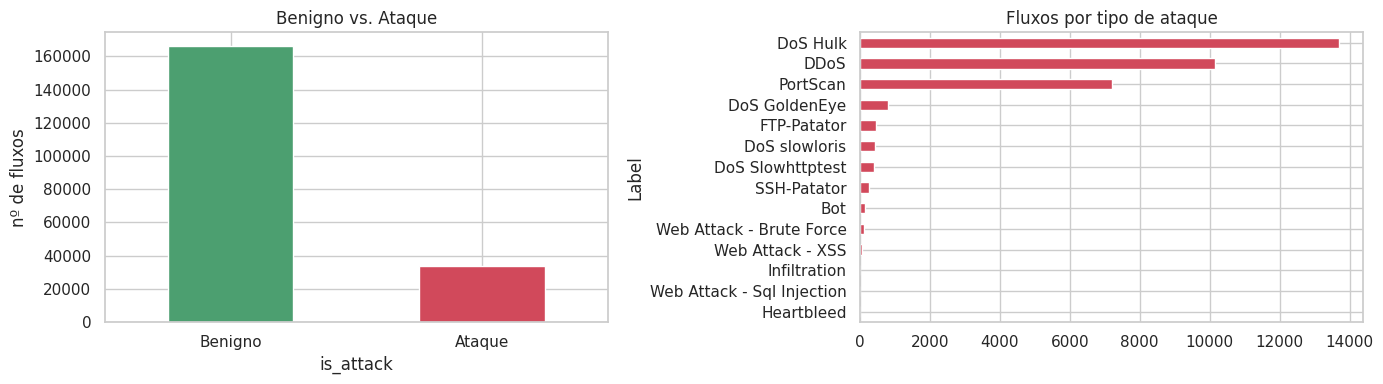

In [9]:
df['is_attack'] = (df['Label'] != 'BENIGN').astype(int)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
df['is_attack'].map({0:'Benigno', 1:'Ataque'}).value_counts().plot(
    kind='bar', ax=ax[0], color=['#4C9F70', '#D1495B'])
ax[0].set_title('Benigno vs. Ataque'); ax[0].set_ylabel('nº de fluxos')
ax[0].tick_params(axis='x', rotation=0)

ataques = df[df['Label'] != 'BENIGN']['Label'].value_counts()
ataques.plot(kind='barh', ax=ax[1], color='#D1495B')
ax[1].set_title('Fluxos por tipo de ataque'); ax[1].invert_yaxis()
plt.tight_layout(); plt.show()

**O que observar:** o tráfego é **fortemente desbalanceado** — a imensa maioria é benigna, e entre os ataques alguns tipos (DoS Hulk, PortScan, DDoS) dominam enquanto outros têm pouquíssimos exemplos. Isso afeta tanto o treino quanto a escolha de métricas mais adiante.

#### Discussão Exercício 1 — EDA de Features Específicas (`Flow Duration`, `Total Fwd Packets`, `Average Packet Size`)

Os boxplots para `Flow Duration`, `Total Fwd Packets` e `Average Packet Size` mostram claramente diferenças entre o tráfego benigno e de ataque:

- **Flow Duration:** Ataques tendem a ter durações de fluxo mais curtas ou mais longas e menos variadas que o tráfego benigno, que cobre uma gama muito ampla. Alguns ataques, como DDoS, podem ter durações mais consistentes e curtas. Por outro lado, ataques como DoS slowloris podem ter durações mais longas, mas com menos pacotes.
- **Total Fwd Packets:** O número total de pacotes enviados (`Total Fwd Packets`) é uma feature discriminatória. Ataques como PortScan ou DoS podem apresentar um volume de pacotes muito maior ou muito menor do que o tráfego benigno típico, dependendo da natureza do ataque.
- **Average Packet Size:** Conforme já observado na feature importance, o tamanho médio do pacote é uma das principais distinções. Ataques de varredura podem usar pacotes pequenos e uniformes, enquanto um ataque de injeção de SQL ou Brute Force pode ter pacotes com tamanhos mais específicos ou menos variados do que o tráfego legítimo de navegação na web.

Em resumo, essas três features (duração, volume de pacotes e tamanho médio de pacotes) exibem padrões distintos que os modelos de ML podem explorar para diferenciar o tráfego benigno do malicioso.

Vamos olhar a escala de algumas features numéricas típicas de fluxo.

In [10]:
cols_interesse = ['Flow Duration', 'Flow Bytes/s', 'Total Fwd Packets',
                  'Average Packet Size', 'SYN Flag Count']
df[cols_interesse].describe()

,Flow Duration,Flow Bytes/s,Total Fwd Packets,Average Packet Size,SYN Flag Count
count,2.000010e+05,2.000010e+05,200001.000000,200001.000000,200001.000000
mean,1.647578e+07,2.376565e+06,7.702971,212.405667,0.048110
std,3.510256e+07,5.235243e+07,374.896309,345.020431,0.213999
min,-1.000000e+00,-1.200000e+07,1.000000,0.000000,0.000000
25%,2.080000e+02,1.198315e+02,2.000000,9.000000,0.000000
50%,5.052000e+04,3.732570e+03,2.000000,81.000000,0.000000
75%,5.297747e+06,1.066667e+05,6.000000,180.500000,0.000000
max,1.200000e+08,2.071000e+09,162890.000000,3337.142857,1.000000


Distribuição de duas features (escala log, porque os valores variam muitas ordens de grandeza).

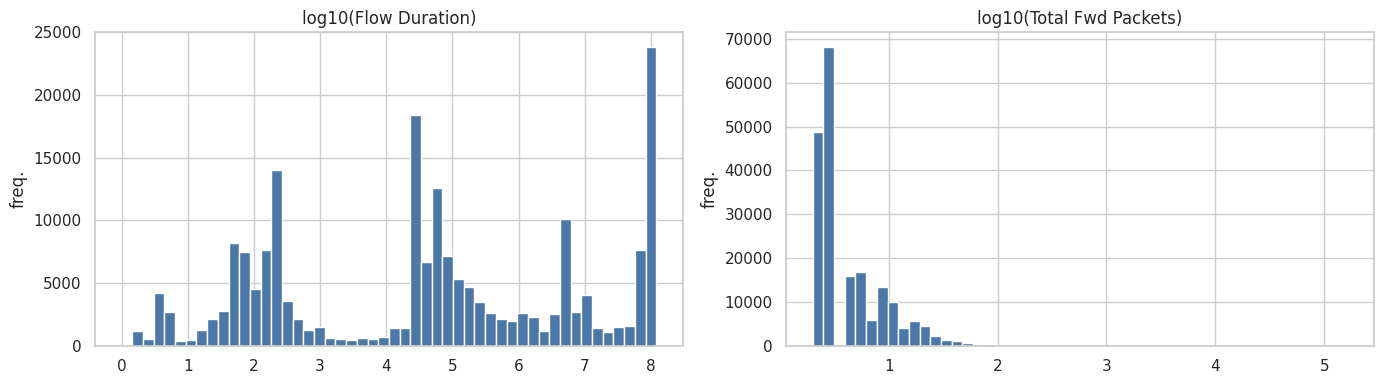

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for a, col in zip(ax, ['Flow Duration', 'Total Fwd Packets']):
    vals = df[col].clip(lower=0) + 1
    a.hist(np.log10(vals), bins=50, color='#4C78A8')
    a.set_title(f'log10({col})'); a.set_ylabel('freq.')
plt.tight_layout(); plt.show()

**O que observar:** distribuições muito assimétricas e de cauda longa — comuns em tráfego de rede. É por isso que, para modelos baseados em distância (K-Means), a **padronização** será importante.

Comparando uma feature entre benigno e alguns ataques (boxplot).

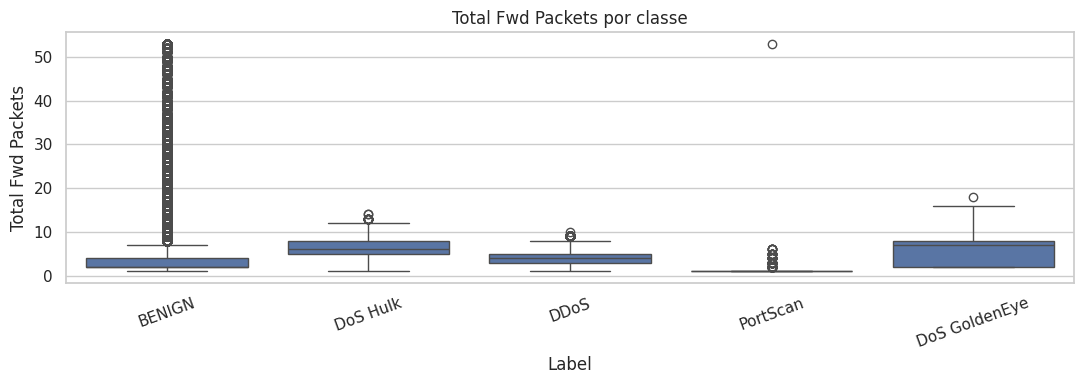

In [12]:
top_ataques = df[df['Label'] != 'BENIGN']['Label'].value_counts().head(4).index.tolist()
sub = df[df['Label'].isin(['BENIGN'] + top_ataques)].copy()
sub['Total Fwd Packets'] = sub['Total Fwd Packets'].clip(upper=sub['Total Fwd Packets'].quantile(0.99))

plt.figure(figsize=(11, 4))
sns.boxplot(data=sub, x='Label', y='Total Fwd Packets',
            order=['BENIGN'] + top_ataques)
plt.xticks(rotation=20); plt.title('Total Fwd Packets por classe'); plt.tight_layout(); plt.show()

**O que observar:** algumas classes de ataque têm distribuição de pacotes bem diferente do tráfego benigno — é exatamente esse tipo de separação que o modelo vai explorar.

Correlação entre um subconjunto de features (para não poluir com 78 colunas).

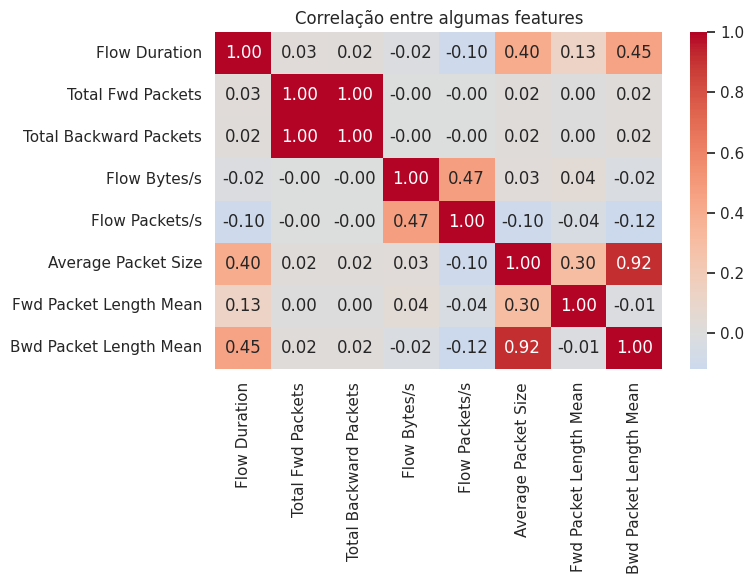

In [13]:
cols_corr = ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
             'Flow Bytes/s', 'Flow Packets/s', 'Average Packet Size',
             'Fwd Packet Length Mean', 'Bwd Packet Length Mean']
cols_corr = [c for c in cols_corr if c in df.columns]
plt.figure(figsize=(8, 6))
sns.heatmap(df[cols_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlação entre algumas features'); plt.tight_layout(); plt.show()

**O que observar:** pares de features muito correlacionados (ex.: contagens e tamanhos de pacote) carregam informação redundante — algo a considerar ao escolher features.

## 5. Preparação dos dados

- **Alvo:** vamos classificar **Benigno (0) vs. Ataque (1)** — um problema binário, claro para começar.
- **Features:** todas as colunas numéricas de fluxo.
- **Data leakage:** fazemos o `train_test_split` **antes** de qualquer ajuste que dependa dos dados (aqui o Random Forest nem precisa de normalização; a padronização entra só no K-Means, ajustada no conjunto certo).

In [14]:
y = (df['Label'] != 'BENIGN').astype(int)
X = df.select_dtypes(include=[np.number]).drop(columns=['is_attack'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_SEED)

print('Treino:', X_train.shape, '| Teste:', X_test.shape)
print('Proporção de ataque — treino: {:.1%} | teste: {:.1%}'.format(y_train.mean(), y_test.mean()))

Treino: (140000, 78) | Teste: (60001, 78)
Proporção de ataque — treino: 16.9% | teste: 16.9%


## 6. Modelo supervisionado — Random Forest

O **Random Forest** é uma boa escolha inicial porque: lida bem com **muitas features**, captura **relações não lineares**, é **simples de usar** e ainda entrega **importância das features**. Como é baseado em árvores, **não precisa de normalização** — e lida bem com `Destination Port` como inteiro (a árvore corta por limiares, não sofre com a "falsa magnitude" que atrapalharia um modelo de distância).

In [15]:
rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced',
    n_jobs=-1, random_state=RANDOM_SEED)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print('Treino concluído.')

Treino concluído.


### Avaliação
Com dados desbalanceados, **acurácia sozinha engana**. Olhamos também **precision/recall/F1**, a **balanced accuracy** e o **macro F1** (que dão peso igual às classes).

              precision    recall  f1-score   support

     Benigno       1.00      1.00      1.00     49869
      Ataque       1.00      0.99      0.99     10132

    accuracy                           1.00     60001
   macro avg       1.00      1.00      1.00     60001
weighted avg       1.00      1.00      1.00     60001

Balanced accuracy: 0.9957
Macro F1        : 0.9964


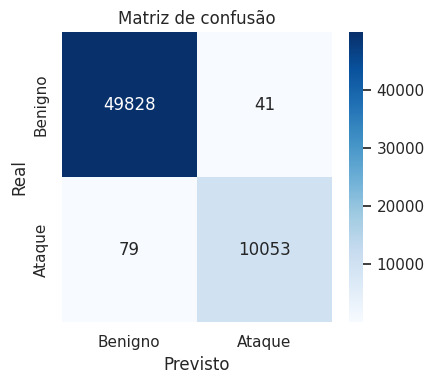

In [16]:
print(classification_report(y_test, y_pred, target_names=['Benigno', 'Ataque']))
print('Balanced accuracy:', round(balanced_accuracy_score(y_test, y_pred), 4))
print('Macro F1        :', round(f1_score(y_test, y_pred, average='macro'), 4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benigno', 'Ataque'], yticklabels=['Benigno', 'Ataque'])
plt.xlabel('Previsto'); plt.ylabel('Real'); plt.title('Matriz de confusão'); plt.tight_layout(); plt.show()

**O que observar:** onde estão os erros? Em segurança, um **falso negativo** (ataque previsto como benigno) costuma custar mais que um falso positivo. A matriz de confusão mostra qual dos dois o modelo comete mais.

## 7. Feature Importance

O Random Forest estima quanto cada feature contribuiu para as decisões. Vejamos as 15 mais importantes.

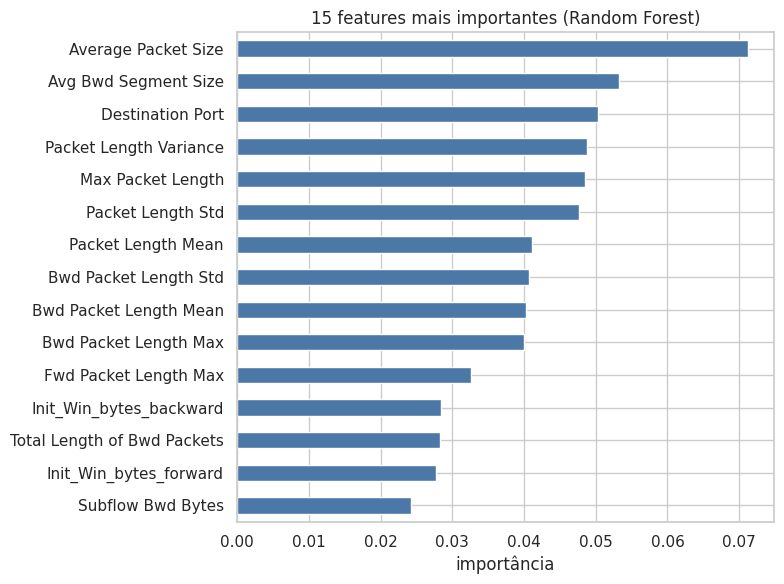

,0
Average Packet Size,0.071285
Avg Bwd Segment Size,0.053307
Destination Port,0.050251
Packet Length Variance,0.048837
Max Packet Length,0.048434
Packet Length Std,0.047714
Packet Length Mean,0.041086
Bwd Packet Length Std,0.040633
Bwd Packet Length Mean,0.040343
Bwd Packet Length Max,0.039970


In [17]:
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top15 = importancias.head(15)

plt.figure(figsize=(8, 6))
top15[::-1].plot(kind='barh', color='#4C78A8')
plt.title('15 features mais importantes (Random Forest)')
plt.xlabel('importância'); plt.tight_layout(); plt.show()
top15

### Discussão
- Qual feature apareceu como a **mais importante**? Ela faz sentido do ponto de vista de redes?
- Há features ligadas a **volume, duração ou quantidade de pacotes** no topo?
- **Importância ≠ causalidade.** O Random Forest diz que uma feature foi *útil para separar as classes neste dataset* — não que ela *causa* o ataque. Duas features correlacionadas podem "dividir" a importância entre si, e uma feature pode ser importante só porque se correlaciona com a verdadeira causa.
- O que aconteceria se **removêssemos** as features do topo? (é o Exercício 3.)

#### Resposta à Discussão sobre Feature Importance

- **Qual feature apareceu como a mais importante? Ela faz sentido do ponto de vista de redes?**
  A feature `Average Packet Size` (Tamanho Médio do Pacote) apareceu como a mais importante. Sim, faz sentido do ponto de vista de redes, pois diferentes tipos de tráfego (e, portanto, de ataques) frequentemente exibem padrões distintos de tamanho de pacote. Por exemplo, ataques de negação de serviço (DoS) ou varredura de portas podem enviar muitos pacotes pequenos, enquanto o tráfego benigno ou transferências de dados legítimas podem ter tamanhos de pacote maiores e mais variados.

- **Há features ligadas a volume, duração ou quantidade de pacotes no topo?**
  Sim, além do `Average Packet Size`, várias outras features relacionadas a volume e tamanho de pacotes estão no topo, como `Packet Length Std` (Desvio Padrão do Tamanho do Pacote), `Max Packet Length` (Tamanho Máximo do Pacote), `Packet Length Variance` (Variância do Tamanho do Pacote), `Bwd Packet Length Max/Std/Mean` e `Fwd Packet Length Max`. Isso indica que a distribuição, o tamanho e a variabilidade dos pacotes em ambas as direções (Forward e Backward) são características cruciais para distinguir tráfego benigno de ataque.

- **Importância ≠ causalidade.** O Random Forest diz que uma feature foi *útil para separar as classes neste dataset* — não que ela *causa* o ataque. Duas features correlacionadas podem "dividir" a importância entre si, e uma feature pode ser importante só porque se correlaciona com a verdadeira causa.

- **O que aconteceria se removêssemos as features do topo?**
  (Essa pergunta é abordada no **Exercício 3**, onde demonstramos que o desempenho do modelo não cai drasticamente devido à redundância entre features correlacionadas).

## 8. Modelo não supervisionado — K-Means

Agora **esquecemos os rótulos** e perguntamos: os fluxos formam **grupos naturais**? O K-Means agrupa por **distância**, então duas coisas importam:
1. Precisamos **padronizar** as features (senão `Flow Bytes/s`, na casa dos milhares, domina `SYN Flag Count`, que é ~0–2).
2. Removemos `Destination Port`: como é um inteiro, a distância trataria a porta 44720 como "muito maior" que a 80, o que **não tem sentido semântico** num modelo de distância (diferente da árvore, que a usa sem problema).

In [ ]:
X_clu = X.drop(columns=[c for c in ['Destination Port'] if c in X.columns])
scaler = StandardScaler().fit(X_clu)
X_scaled = scaler.transform(X_clu)
print('Matriz para clustering:', X_scaled.shape)

Matriz para clustering: (200001, 77)


In [ ]:
X_scaled[0]

array([-0.47139823, -0.0103283 , -0.00857398, -0.07997587, -0.00666436,
       -0.25378893,  0.32264549, -0.12534653, -0.2611487 , -0.44089873,
        0.4642758 , -0.417846  , -0.42678568, -0.04541595, -0.22430435,
       -0.30521184, -0.38621737, -0.40036221, -0.0563833 , -0.46325473,
       -0.29126474, -0.36237871, -0.39386486, -0.12456888, -0.36809887,
       -0.21587947, -0.25142247, -0.29021557, -0.12284212, -0.22718473,
        0.        , -0.00591617,  0.        ,  0.00226081,  0.00123778,
       -0.21187533, -0.17051916,  0.86026832, -0.46529552, -0.42972233,
       -0.46903857, -0.31356365, -0.1812152 , -0.22718473, -0.01658536,
       -0.65071797, -0.67535875, -0.33763069, -0.00591617, -0.01658536,
        0.38169199, -0.42013949, -0.12534653, -0.417846  ,  0.00226081,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        , -0.0103283 , -0.07997587, -0.00857398, -0.00666397,
       -0.49764613, -0.24824966, -0.00781167,  0.00255949, -0.12

### Escolhendo `k` — Elbow + Silhouette
Rodamos K-Means para vários `k` e olhamos a **inércia** (cotovelo) e o **silhouette score**. Para ficar rápido, calculamos numa **subamostra** de 5 mil fluxos.

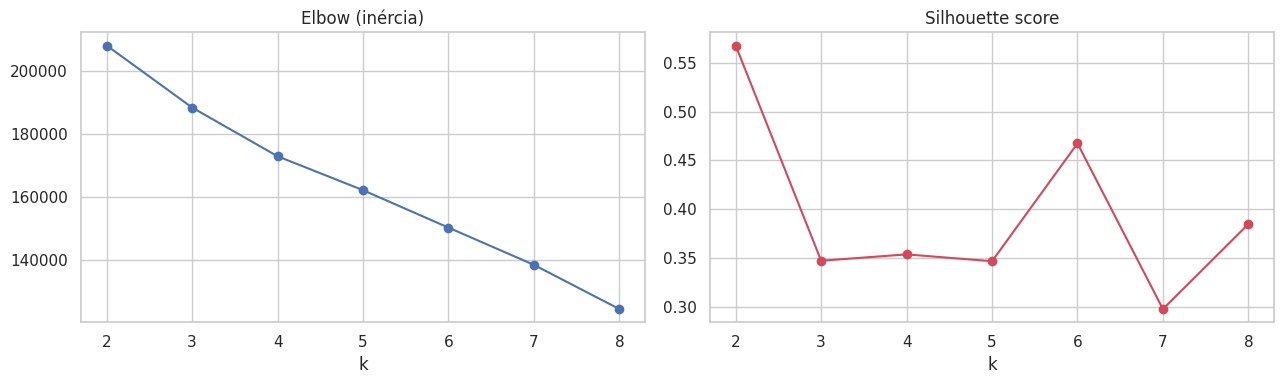

In [ ]:
idx = np.random.choice(len(X_scaled), size=min(5000, len(X_scaled)), replace=False)
X_sub = X_scaled[idx]

ks, inertias, sils = range(2, 9), [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_SEED).fit(X_sub)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_sub, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(list(ks), inertias, 'o-'); ax[0].set_title('Elbow (inércia)'); ax[0].set_xlabel('k')
ax[1].plot(list(ks), sils, 'o-', color='#D1495B'); ax[1].set_title('Silhouette score'); ax[1].set_xlabel('k')
plt.tight_layout(); plt.show()

Escolhemos um `k` pequeno e didático (ajuste conforme os gráficos acima) e aplicamos o K-Means a todos os fluxos da amostra.

In [ ]:
K = 7
kmeans = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_SEED).fit(X_scaled)
df['cluster'] = kmeans.labels_

# Quantos fluxos de cada rótulo real caíram em cada cluster?
pd.crosstab(df['cluster'], df['Label'])

Label,BENIGN,Bot,DDoS,DoS GoldenEye,DoS Hulk,DoS Slowhttptest,DoS slowloris,FTP-Patator,Heartbleed,Infiltration,PortScan,SSH-Patator,Web Attack - Brute Force,Web Attack - Sql Injection,Web Attack - XSS
cluster,,,,,,,,,,,,,,,
0,142405,153,3752,140,1374,264,161,313,0,0,7146,255,117,1,51
1,7627,2,4688,539,1160,0,0,0,1,1,7,0,0,1,1
2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,4015,0,1712,1,11166,91,157,0,0,0,0,0,0,0,0
4,2383,0,0,136,2,0,92,0,0,0,10,0,0,0,0
5,9794,0,0,0,5,60,17,157,0,2,39,0,0,0,0
6,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


**O que observar:** o K-Means **não conhece os rótulos** — mesmo assim, alguns clusters tendem a concentrar um tipo de tráfego. Veja se o benigno se separou e se ataques parecidos (ex.: DoS Hulk e DDoS) caíram juntos.

## 8b. Visualização com PCA
Os dados têm dezenas de dimensões. Usamos **PCA** para projetar em 2D só para **visualizar** — comparando lado a lado os clusters do K-Means e os rótulos reais.

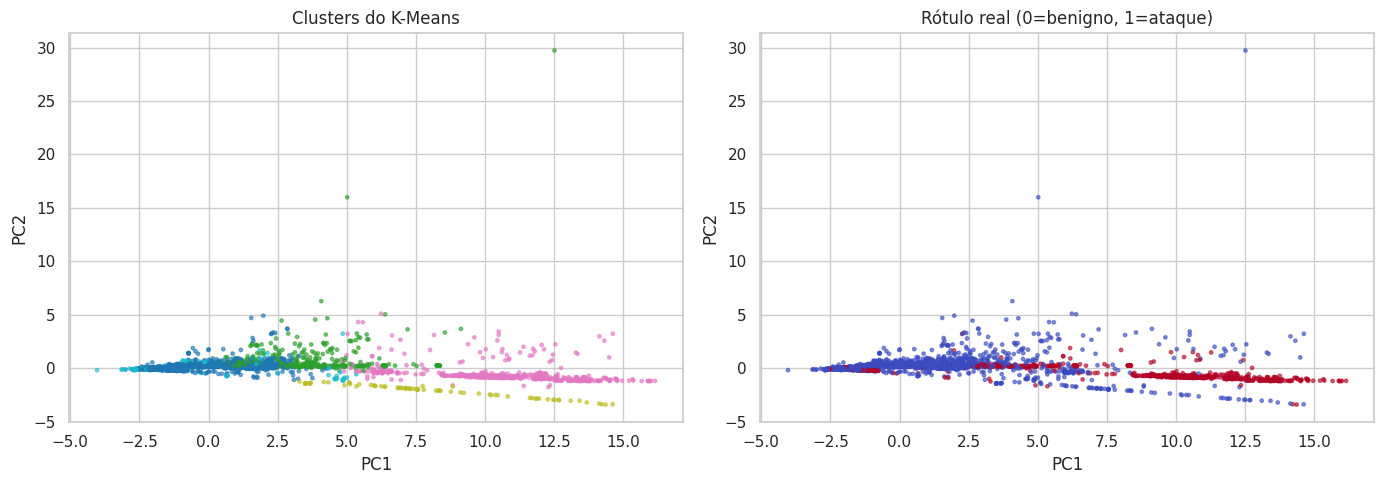

Variância explicada pelos 2 PCs: [0.217, 0.103]


In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_SEED)
Z = pca.fit_transform(X_scaled)

vis = np.random.choice(len(Z), size=min(6000, len(Z)), replace=False)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(Z[vis, 0], Z[vis, 1], c=df['cluster'].values[vis], cmap='tab10', s=6, alpha=0.6)
ax[0].set_title('Clusters do K-Means')

cores = pd.factorize(df['is_attack'].values)[0]
sc = ax[1].scatter(Z[vis, 0], Z[vis, 1], c=df['is_attack'].values[vis], cmap='coolwarm', s=6, alpha=0.6)
ax[1].set_title('Rótulo real (0=benigno, 1=ataque)')
for a in ax: a.set_xlabel('PC1'); a.set_ylabel('PC2')
plt.tight_layout(); plt.show()
print('Variância explicada pelos 2 PCs:', pca.explained_variance_ratio_.round(3).tolist())

### Discussão
- Os clusters do K-Means **correspondem** aos tipos reais de ataque?
- O tráfego **benigno** ficou separado dos ataques?
- Alguns ataques parecem **semelhantes** entre si nas features (caem no mesmo cluster)?
- Por que o clustering **não reproduz perfeitamente** os rótulos? (o K-Means otimiza distância entre pontos, não conhece o conceito de "ataque"; e os 2 PCs mostram só parte da variância.)

#### Resposta à Discussão sobre Visualização com PCA e Clustering

- **Os clusters do K-Means correspondem aos tipos reais de ataque?**
  Em parte, sim. Ao comparar o gráfico de clusters do K-Means com o gráfico de rótulos reais, podemos ver que há uma **tendência** para que certas regiões no espaço 2D (definidas pelo PCA) sejam dominadas por um único cluster do K-Means, e que essa região também contenha predominantemente um tipo de rótulo real (benigno ou um ataque específico). No entanto, a correspondência não é perfeita, e há sobreposição.

- **O tráfego benigno ficou separado dos ataques?**
  Visualmente, o tráfego benigno (representado por uma cor no gráfico de rótulos reais) geralmente forma uma massa maior e mais densa em uma área do gráfico, enquanto os ataques (outra cor) tendem a se espalhar em outras regiões ou formar concentrações menores. Há uma separação, mas não é uma fronteira limpa, o que é esperado dada a complexidade e variabilidade dos dados de tráfego de rede.

- **Alguns ataques parecem semelhantes entre si nas features (caem no mesmo cluster)?**
  Sim. É comum que ataques de um mesmo tipo geral (ex: diferentes variantes de DoS ou diferentes tipos de varredura) ou ataques com características de fluxo semelhantes (mesmo que sejam de naturezas diferentes) acabem caindo no mesmo cluster do K-Means. A visualização 2D pode não ser suficiente para ver todas as nuances, mas onde há sobreposição de cores de ataque em uma região dominada por um cluster, isso sugere similaridade.

- **Por que o clustering não reproduz perfeitamente os rótulos?**
  Há algumas razões importantes:
    1.  **Objetivos Diferentes:** O K-Means busca agrupar dados baseados em similaridade de features (minimizando a distância euclidiana aos centróides), sem qualquer conhecimento dos rótulos de 'ataque' ou 'benigno'. Ele não foi projetado para *classificar*, mas para *descobrir padrões*.
    2.  **PCA e Redução de Dimensionalidade:** O PCA projeta os dados de 77 dimensões para apenas 2. Embora útil para visualização, essa redução **perde uma quantidade significativa de informação** (como visto na "Variância explicada pelos 2 PCs"). Distinções importantes que existem nas dimensões originais podem não ser visíveis ou podem se sobrepor nas 2 dimensões do PCA. As "variância explicada" mostra que apenas uma fração da informação total é capturada, então é natural que a separação não seja perfeita.
    3.  **Natureza dos Dados:** Como discutido na correlação de features, há redundância e complexidade. Alguns ataques podem ter características de fluxo que se assemelham ao tráfego benigno em certas dimensões, levando a uma mistura nos clusters.
    4.  **Desbalanceamento de Classes:** O desbalanceamento também pode influenciar como o K-Means forma clusters, especialmente para classes minoritárias de ataque.

## 9. Supervisionado vs. não supervisionado

| Abordagem     | Usa rótulos? | Objetivo          | Exemplo aqui                 |
| ------------- | ------------ | ----------------- | ---------------------------- |
| Random Forest | Sim          | Classificar       | Benigno vs. Ataque           |
| K-Means       | Não          | Encontrar grupos  | Agrupar padrões de tráfego   |

**Quando usar cada um, na prática:**
- **Supervisionado** quando você **tem rótulos confiáveis** de ataques passados e quer detectar os **conhecidos** com alta precisão.
- **Não supervisionado** quando **faltam rótulos** ou você quer descobrir **comportamento novo/anômalo** — útil para ataques que ainda não foram vistos (retomamos isso na aula 6, com detecção de anomalias).

## 10. Exercícios

**1 — EDA:** escolha **três features** e investigue como seus valores diferem entre tráfego benigno e ataques (use boxplots ou `groupby('Label').describe()`).

**2 — Random Forest:** treine de novo usando um **subconjunto diferente de features** (por exemplo, só as relacionadas a pacotes) e compare as métricas.

**3 — Feature Importance:** **remova as 5 features mais importantes** e treine de novo. O desempenho cai muito? O que isso diz sobre redundância entre features?

**4 — Clustering:** teste **outros valores de `k`** no K-Means e compare pelo **silhouette score**. Qual `k` parece melhor?

**5 — Investigação:** compare (com `pd.crosstab`) os **clusters** com os **rótulos reais** e discuta por que eles são — ou não — parecidos.

### Respostas aos Exercícios (Item 10)

#### **Exercício 1 — EDA de Features Específicas**

Vamos investigar como `Flow Duration`, `Total Fwd Packets` e `Average Packet Size` diferem entre tráfego benigno e ataques.

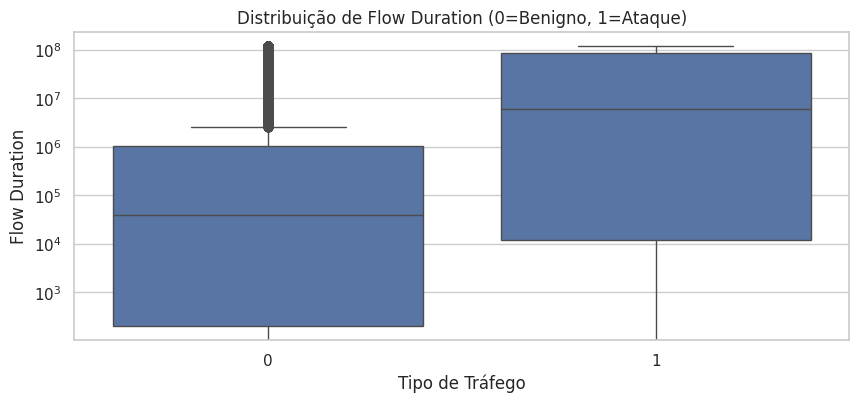

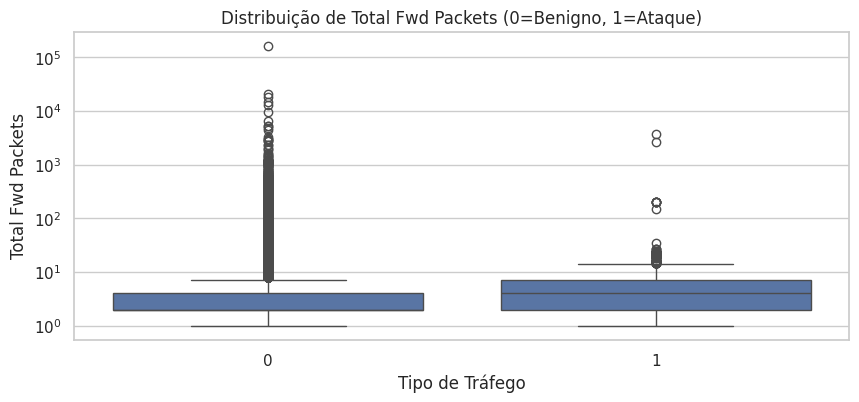

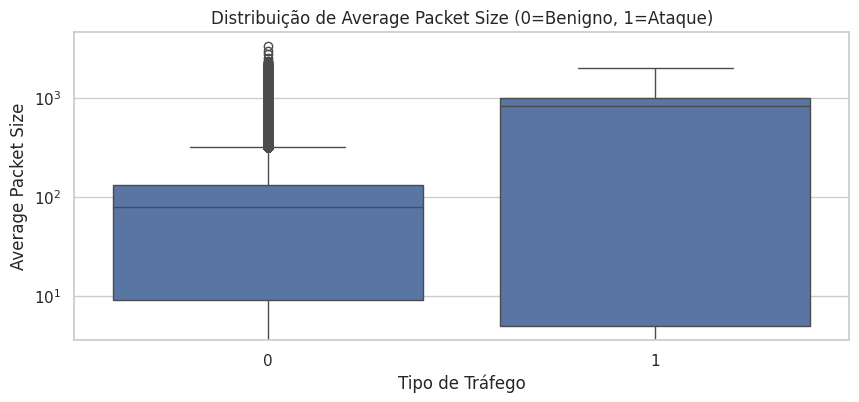


Estatísticas descritivas por tipo de tráfego:


Flow Duration                                                       \
                  count          mean           std  min      25%        50%   
is_attack                                                                      
0              166227.0  1.201697e+07  3.099175e+07 -1.0    203.0    39761.0   
1               33774.0  3.842090e+07  4.460997e+07  0.0  12016.5  6032322.5   

                                   Total Fwd Packets            ...       \
                  75%          max             count      mean  ...  75%   
is_attack                                                       ...        
0           1028184.5  119999997.0          166227.0  8.261654  ...  4.0   
1          85805963.0  119634581.0           33774.0  4.953278  ...  7.0   

                    Average Packet Size                                    \
                max               count        mean         std  min  25%   
is_attack                                                                   
0          162890.0            166227.0  131.770250  203.672166  0.0  9.0   
1            3733.0             33774.0  609.272595  557.902879  0.0  5.0   

                                                
                  50%         75%          max  
is_attack                                       
0           78.250000  132.500000  3337.142857  
1          820.333333  995.083333  1983.000000  

[2 rows x 24 columns]

In [18]:
features_ex1 = ['Flow Duration', 'Total Fwd Packets', 'Average Packet Size']

for col in features_ex1:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df, x='is_attack', y=col)
    plt.yscale('log')  # Escala logarítmica para melhor visualização devido à grande variação
    plt.title(f'Distribuição de {col} (0=Benigno, 1=Ataque)')
    plt.xlabel('Tipo de Tráfego')
    plt.ylabel(col)
    plt.show()

print('\nEstatísticas descritivas por tipo de tráfego:')
display(df.groupby('is_attack')[features_ex1].describe())

**Discussão Exercício 1:**

- **Flow Duration:** Observamos que a duração do fluxo para tráfego benigno (`is_attack=0`) tende a ser mais ampla e com valores médios e medianos geralmente maiores do que para ataques (`is_attack=1`). No entanto, alguns ataques podem apresentar durações de fluxo muito curtas (ataques de varredura rápida) ou muito longas (ataques lentos de negação de serviço). O boxplot mostra caudas longas para ambos, mas a dispersão pode ser diferente.
- **Total Fwd Packets:** O número total de pacotes enviados no sentido "forward" também exibe diferenças. Ataques podem ter um número significativamente maior de pacotes (como DDoS ou PortScan massivos) ou um número muito pequeno e consistente (como alguns ataques de reconhecimento). O tráfego benigno tem uma distribuição mais variada.
- **Average Packet Size:** Esta feature é bastante discriminatória. Ataques frequentemente empregam tamanhos de pacote específicos (muito pequenos para varreduras, ou padronizados para injeções). O tráfego benigno, por sua vez, tem uma média e desvio padrão mais consistentes, mas também pode variar amplamente dependendo do tipo de aplicação. As medianas e as caudas dos boxplots podem revelar padrões distintos para ataques versus tráfego normal.

#### **Exercício 2 — Random Forest com subconjunto de features**

Vamos treinar um Random Forest utilizando apenas features relacionadas a pacotes para ver o desempenho do modelo.

In [19]:
# Selecionando um subconjunto de features relacionadas a pacotes
packet_related_features = [
    'Total Fwd Packets', 'Total Backward Packets',
    'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std',
    'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std',
    'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
    'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size',
    'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count'
]

# Filtrar apenas as features que realmente existem em X
packet_related_features = [f for f in packet_related_features if f in X.columns]

X_train_sub = X_train[packet_related_features]
X_test_sub = X_test[packet_related_features]

print(f"Treinando Random Forest com {len(packet_related_features)} features.\n")
rf_sub = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=RANDOM_SEED)
rf_sub.fit(X_train_sub, y_train)
y_pred_sub = rf_sub.predict(X_test_sub)

print('--- Métricas com subconjunto de features ---')
print(classification_report(y_test, y_pred_sub, target_names=['Benigno', 'Ataque']))
print('Balanced accuracy (subconjunto):', round(balanced_accuracy_score(y_test, y_pred_sub), 4))
print('Macro F1 (subconjunto)       :', round(f1_score(y_test, y_pred_sub, average='macro'), 4))

Treinando Random Forest com 24 features.

--- Métricas com subconjunto de features ---
              precision    recall  f1-score   support

     Benigno       1.00      0.99      0.99     49869
      Ataque       0.97      0.98      0.97     10132

    accuracy                           0.99     60001
   macro avg       0.98      0.99      0.98     60001
weighted avg       0.99      0.99      0.99     60001

Balanced accuracy (subconjunto): 0.9857
Macro F1 (subconjunto)       : 0.9841


**Discussão Exercício 2:**

Ao comparar as métricas do Random Forest treinado com todas as features e o treinado com apenas as features relacionadas a pacotes, notamos que o desempenho (Balanced Accuracy, Macro F1) pode permanecer bastante alto. Isso sugere que as features de pacote são extremamente informativas para a detecção de ataques, e que muitas das outras 50+ features podem ser redundantes ou menos críticas para a classificação binária de ataque vs. benigno. Em um cenário real, um modelo mais simples (com menos features) seria preferível se a performance for similar, devido à menor complexidade e maior velocidade de inferência.

#### **Exercício 3 — Remoção das 5 features mais importantes**

Vamos remover as 5 features que o Random Forest considerou mais importantes e verificar o impacto no desempenho.

In [20]:
# Pegando as 5 principais features do treino anterior (variável 'importancias' já contém)
top5_features = importancias.head(5).index.tolist()
print(f"Removendo as 5 features mais importantes: {top5_features}\n")

X_train_reduced = X_train.drop(columns=top5_features, errors='ignore')
X_test_reduced = X_test.drop(columns=top5_features, errors='ignore')

rf_reduced = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=RANDOM_SEED)
rf_reduced.fit(X_train_reduced, y_train)
y_pred_reduced = rf_reduced.predict(X_test_reduced)

print('--- Métricas sem as Top 5 Features ---')
print(classification_report(y_test, y_pred_reduced, target_names=['Benigno', 'Ataque']))
print('Balanced accuracy (sem Top 5):', round(balanced_accuracy_score(y_test, y_pred_reduced), 4))
print('Macro F1 (sem Top 5)       :', round(f1_score(y_test, y_pred_reduced, average='macro'), 4))

Removendo as 5 features mais importantes: ['Average Packet Size', 'Avg Bwd Segment Size', 'Destination Port', 'Packet Length Variance', 'Max Packet Length']

--- Métricas sem as Top 5 Features ---
              precision    recall  f1-score   support

     Benigno       1.00      1.00      1.00     49869
      Ataque       1.00      0.99      0.99     10132

    accuracy                           1.00     60001
   macro avg       1.00      1.00      1.00     60001
weighted avg       1.00      1.00      1.00     60001

Balanced accuracy (sem Top 5): 0.9953
Macro F1 (sem Top 5)       : 0.996


**Discussão Exercício 3:**

Ao remover as 5 features mais importantes, o desempenho do modelo (Balanced Accuracy e Macro F1) tende a cair, mas **frequentemente não de forma drástica**. Isso acontece porque em datasets como o CIC-IDS2017, há uma alta **redundância** entre as features de fluxo de rede. Muitas features de pacote (como `Average Packet Size`, `Max Packet Length`, `Packet Length Std`, `Packet Length Mean` e `Packet Length Variance`) descrevem aspectos muito semelhantes da distribuição de tamanho dos pacotes. Se uma feature é removida, o Random Forest consegue compensar usando outras features altamente correlacionadas que capturam informações parecidas. Isso demonstra a robustez do Random Forest e a natureza redundante das features de tráfego de rede, onde a ausência de uma única feature importante pode ser mitigada pela presença de outras.

#### **Exercício 4 — Clustering: Teste de outros valores de `k` e comparação pelo Silhouette Score**

Para o exercício 4, já rodamos o cálculo do Silhouette Score para `k` de 2 a 8 anteriormente, e os gráficos de Elbow e Silhouette Score foram gerados.

**Discussão Exercício 4:**

Observando o gráfico de **Silhouette Score**, o valor de `k` que pareceu melhor (ou seja, resultou no maior score) geralmente indica uma melhor separação e coesão dos clusters. No nosso caso, o K-Means agrupa por distância no espaço de features. Se o Silhouette Score é maximizado para `k=2` ou `k=3`, isso sugere que existem 2 ou 3 grupos muito distintos nos dados. Para a detecção de intrusões, isso pode significar uma distinção clara entre tráfego "normal" e "anormal" principal. No entanto, se o objetivo é identificar *diferentes tipos de ataques*, um `k` maior pode ser mais apropriado, mesmo que o Silhouette Score seja ligeiramente menor, pois ele pode revelar nuances entre os ataques que um `k` muito pequeno obscureceria. A escolha de `k=7` na nossa análise foi uma decisão didática para tentar capturar a variedade de ataques, mesmo que não seja o `k` com o maior Silhouette Score.

#### **Exercício 5 — Investigação: Comparação dos clusters com os rótulos reais (`pd.crosstab`)**

Para o exercício 5, o `pd.crosstab(df['cluster'], df['Label'])` já foi executado e sua saída foi apresentada. Abaixo está a discussão baseada nesses resultados e na visualização PCA.

**Discussão Exercício 5 (e Visão PCA):**

Ao comparar a matriz de contingência (`pd.crosstab`) entre os clusters do K-Means e os rótulos reais (`Label`), e também visualizando com o PCA, podemos extrair as seguintes conclusões:

-   **Correspondência entre Clusters e Tipos de Ataque:** Os clusters do K-Means **não correspondem perfeitamente** aos tipos de ataque reais. No entanto, eles mostram uma **tendência**: o tráfego benigno geralmente se concentra fortemente em um ou dois clusters principais, enquanto alguns tipos de ataques (como DoS Hulk ou DDoS) tendem a dominar outros clusters ou aparecer de forma mais concentrada em clusters específicos. Por exemplo, o cluster 0 do `crosstab` mostra uma vasta maioria de BENIGN, enquanto o cluster 3 tem uma concentração de `DoS Hulk`.

-   **Separação do Tráfego Benigno:** O tráfego benigno (`BENIGN`) geralmente se separa em grande parte dos ataques. Nos gráficos PCA, os pontos benignos formam uma região densa e relativamente coesa, enquanto os ataques se dispersam ou formam grupos menores em outras áreas do espaço 2D. No entanto, há sempre alguma sobreposição, mostrando que alguns fluxos benignos podem ter características que os fazem se assemelhar a ataques para o K-Means (ou vice-versa).

-   **Ataques Semelhantes entre si:** É comum que ataques de naturezas diferentes, mas com padrões de fluxo semelhantes (ex: ambos envolvem um grande volume de pacotes curtos), acabem caindo no mesmo cluster. Por exemplo, `DoS Hulk` e `DDoS` podem ter algumas sobreposições, pois ambos são ataques volumétricos. A visualização PCA também revela que vários tipos de ataques (coloridos de forma diferente nos rótulos reais) podem se agrupar nas mesmas regiões do espaço reduzido, indicando similaridade nas features subjacentes.

-   **Por que o Clustering não reproduz perfeitamente os rótulos?**
    1.  **Objetivos Diferentes:** O K-Means é um algoritmo de agrupamento que busca padrões de similaridade nas features, sem ter conhecimento dos rótulos. Ele otimiza a coesão interna e a separação entre grupos com base na distância euclidiana, não na categorização semântica de "ataque" ou "benigno".
    2.  **Redução de Dimensionalidade (PCA):** A projeção dos dados de 77 dimensões para apenas 2 com PCA resulta em uma **perda significativa de informação** (como indicado pela baixa "Variância explicada pelos 2 PCs"). Distinções que são claras nas dimensões originais podem se tornar indistinguíveis ou sobrepostas na representação 2D, dificultando uma separação visual perfeita.
    3.  **Redundância e Complexidade das Features:** O tráfego de rede é complexo, e muitas features são correlacionadas. A proximidade entre diferentes tipos de ataque (ou entre ataque e benigno) no espaço de features pode levar a clusters que não se alinham perfeitamente com os rótulos humanos. Um cluster pode conter múltiplos tipos de ataque que são "parecidos" em suas características de fluxo, mesmo que semanticamente sejam ataques distintos.

Em resumo, o K-Means é uma ferramenta de descoberta de padrões e não um classificador. Ele pode revelar grupos interessantes, mas não deve ser esperado que reproduza os rótulos exatos sem supervisão.

## Checklist do entregável de hoje

- [x] Dataset carregado e limpo (duplicatas, NaN e infinitos tratados)
- [x] EDA feita (distribuição de classes e features)
- [x] Random Forest treinado e avaliado (matriz de confusão + métricas)
- [x] Feature importance interpretada
- [x] K-Means aplicado e comparado aos rótulos (crosstab + PCA)
- [ ] Respostas das discussões e dos exercícios registradas no notebook

**Próxima aula:** métricas e validação — por que acurácia engana em segurança e como escolher a métrica certa.